In [60]:
from FS_NBRGDS_Interval_Tensor import FS_NBRGDS_tensor
from tqdm.auto import tqdm
import torch
%load_ext Cython
%load_ext autoreload
%autoreload 2

# The easiest situation: deep=1

In [61]:
V=12
T=300
sys = torch.zeros(T, V)
high_value = 50
low_value = 0
############# Stage 1 #############
sys[0:100, 0:4] = torch.poisson(high_value*torch.ones(100,4))        # 1st community
############# Stage 2 #############
sys[100:200, 4:8] = torch.poisson(high_value*torch.ones(100,4))        # 2st community
############# Stage 3 #############
sys[200:300, 8:12] = torch.poisson(high_value*torch.ones(100,4))        # 3st community

burnin = 60
maxiter = 20
params = {
'tau': 1.,
'psi':2.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
}
params['data'] = sys
params['K'] = 12
params['S'] = 60

fs_nbrgds = FS_NBRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# design phi we could get correct estimation of intensity under K=3
fs_nbrgds.phi[0][:,:] = 0.
fs_nbrgds.phi[0][0:4,0:4] = 0.25
fs_nbrgds.phi[0][4:8,4:8] = 0.25
fs_nbrgds.phi[0][8:12,8:12] = 0.25
fs_nbrgds.pi  = torch.tile(fs_nbrgds.phi[0], (params['S'],1,1)) 
fs_nbrgds.pit = torch.tile(fs_nbrgds.phi[0], (T,1,1))
for iter in tqdm(range(burnin+maxiter)):
    fs_nbrgds.sample_n()
    fs_nbrgds.sample_h()
    fs_nbrgds.sample_aux_h()
    fs_nbrgds.sample_the()
    fs_nbrgds.sample_lam()
    fs_nbrgds.sample_delt()
    fs_nbrgds.sample_g()
    fs_nbrgds.sample_gam()
    fs_nbrgds.sample_beta()
    fs_nbrgds.sample_phi()
    fs_nbrgds.sample_pi()
    fs_nbrgds.sample_eta()
    fs_nbrgds.sample_A()
    fs_nbrgds.sample_dpgm()

    if iter > burnin:
        esti_temp = fs_nbrgds.phi[0] @ torch.diag(fs_nbrgds.lam) @ (fs_nbrgds.the).T @ torch.diag(fs_nbrgds.delt)
        esti_steady.append(esti_temp.clone())
        transition_steady.append(fs_nbrgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 0.4724 seconds
sample_h took 0.1409 seconds
sample_aux_h took 1.0910 seconds
sample_the took 0.0101 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0006 seconds
sample_g took 0.0006 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0035 seconds
sample_pi took 0.0634 seconds
sample_eta took 0.0011 seconds
Sum over self.A:  tensor(4835)
sample_A took 2.5120 seconds
sample_dpgm took 0.1333 seconds
sample_n took 0.4612 seconds
sample_h took 0.1309 seconds
sample_aux_h took 1.0296 seconds
sample_the took 0.0013 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0002 seconds
sample_g took 0.0006 seconds
sample_gam took 0.0001 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0019 seconds
sample_pi took 0.0629 seconds
sample_eta took 0.0008 seconds
Sum over self.A:  tensor(2657)
sample_A took 1.7724 seconds
sample_dpgm took 0.1341 seconds
sample_n took 0.4576 seconds
sample_h took 0.1306 seconds
sample_aux_h took 1.

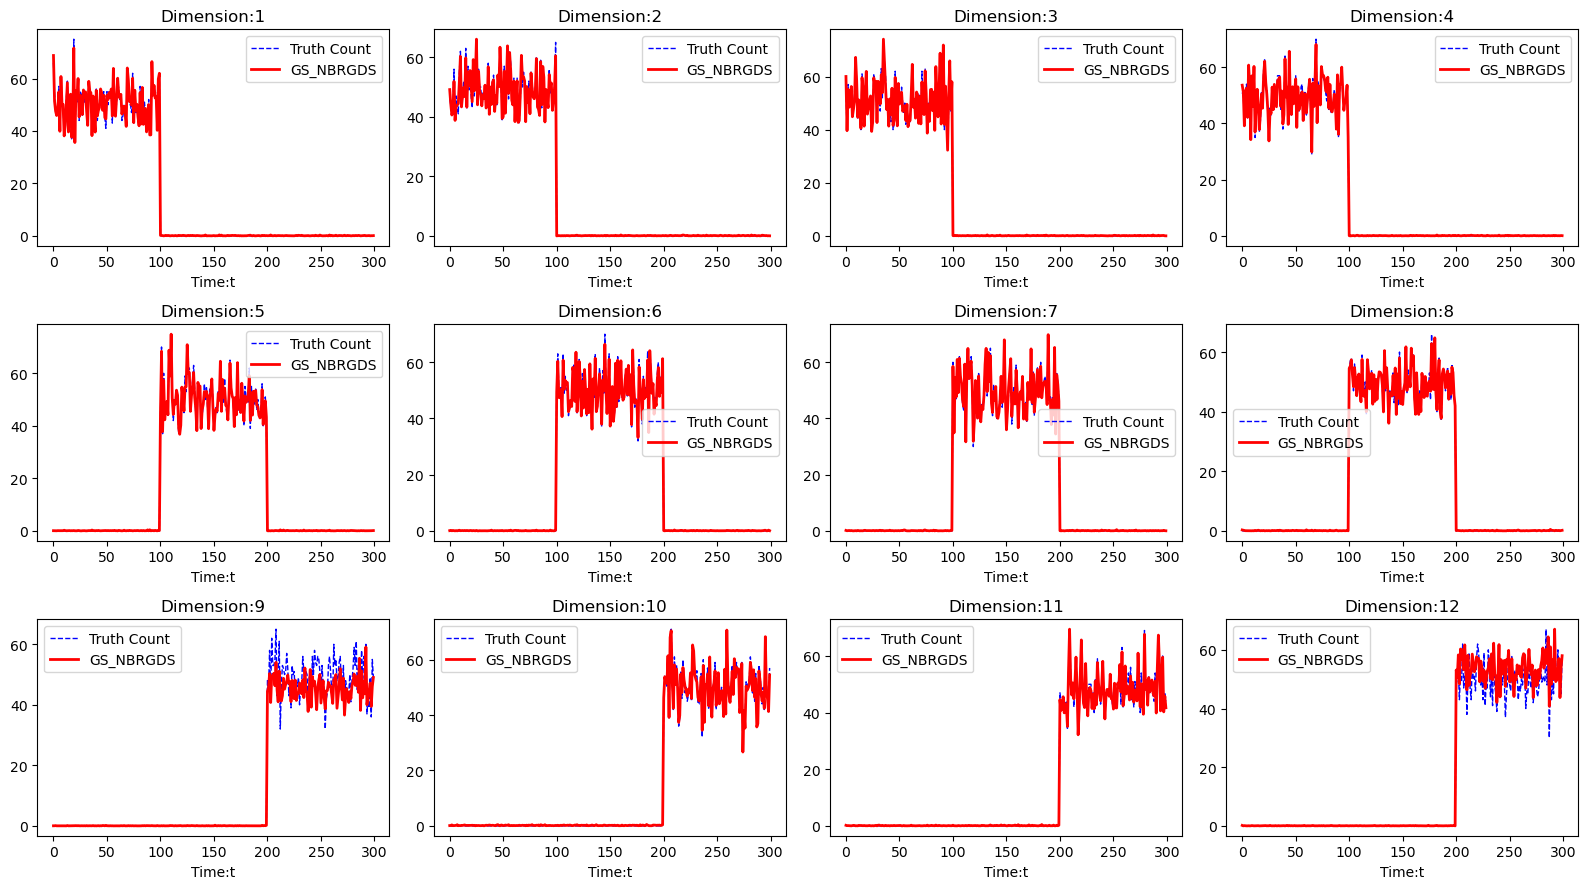

In [62]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
esti_steady = torch.stack(esti_steady)
esti_mean = torch.mean(esti_steady, axis = 0)
fig, axs = plt.subplots(3,4, figsize=(16,9))
for i, ax in enumerate(axs.flatten()):
    ax.plot(sys[:,i], color = 'blue', linewidth = 1, linestyle = '--', label = 'Truth Count')
    ax.plot(esti_mean[i], color = 'red', linewidth = 2, label = 'GS_NBRGDS')
    ax.set_title(f'Dimension:{i+1}')
    ax.set_xlabel('Time:t')
    ax.legend()
plt.tight_layout()
plt.show()

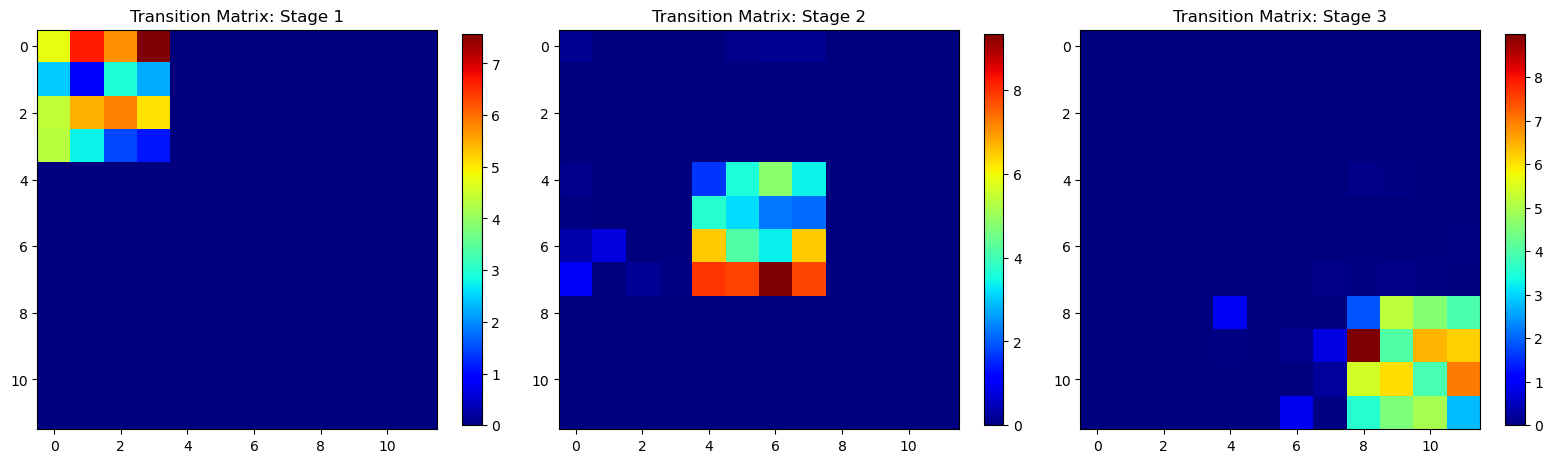

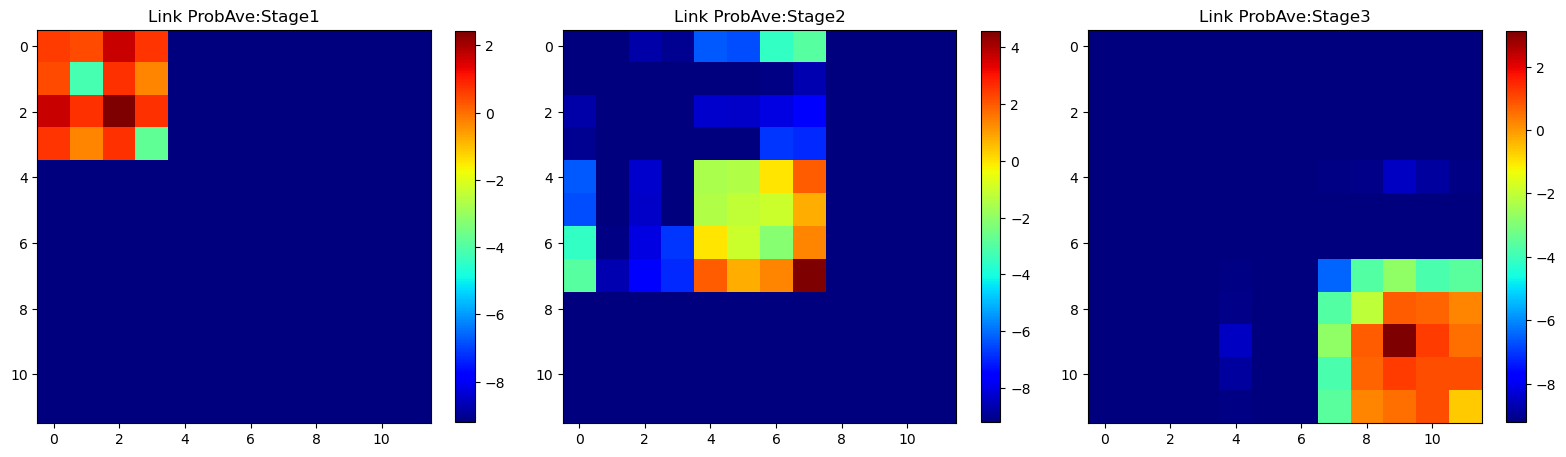

In [5]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(16, 9))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[4:20], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (16,9))
for i in range(3):
    if i == 0:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[4:20], axis = 0)
    else:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(torch.log(ProbAve + ProbAve.T + 0.0001), cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

# Deep=2, mode 1 = 60, mode 2 = 60, time = 300, interval = 3, community=20*20

In [6]:
# generate sysnthetic data
T = 300
S = 3
high_value = 10
sys = torch.zeros(T,60,60)
sys[0:100, 0:20, 0:20] = torch.poisson(high_value*torch.ones(100,20,20))
sys[100:200, 20:40, 20:40] = torch.poisson(high_value*torch.ones(100,20,20))
sys[200:300, 40:60, 40:60] = torch.poisson(high_value*torch.ones(100,20,20))

In [9]:
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1.,
'psi':2.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 30, # latent components
'S' : 60 # sub-intervals
}

fs_nbrgds = FS_NBRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
fs_nbrgds.phi[0][:,:] = 0.
fs_nbrgds.phi[0][0:20,0:10] = 1/20
fs_nbrgds.phi[0][20:40,10:20] = 1/20
fs_nbrgds.phi[0][40:60,20:30] = 1/20
fs_nbrgds.phi[1][:,:] = 0.
fs_nbrgds.phi[1][0:20,0:10] = 1/20
fs_nbrgds.phi[1][20:40,10:20] = 1/20
fs_nbrgds.phi[1][40:60,20:30] = 1/20

initial_pi = torch.zeros(30,30)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
fs_nbrgds.pi  = torch.tile(initial_pi, (params['S'],1,1))
fs_nbrgds.pit = torch.tile(initial_pi, (T,1,1))
for iter in tqdm(range(burnin+maxiter)):
    fs_nbrgds.sample_n()
    fs_nbrgds.sample_h()
    fs_nbrgds.sample_aux_h()
    fs_nbrgds.sample_the()
    fs_nbrgds.sample_lam()
    fs_nbrgds.sample_delt()
    fs_nbrgds.sample_g()
    fs_nbrgds.sample_gam()
    fs_nbrgds.sample_beta()
    fs_nbrgds.sample_phi()
    fs_nbrgds.sample_pi()
    fs_nbrgds.sample_eta()
    fs_nbrgds.sample_A()
    fs_nbrgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(fs_nbrgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 56.7890 seconds
sample_h took 0.4025 seconds
sample_aux_h took 3.3101 seconds
sample_the took 0.0021 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0037 seconds
sample_g took 0.0019 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0510 seconds
sample_pi took 0.2083 seconds
sample_eta took 0.0014 seconds
Sum over self.A:  tensor(13710)
sample_A took 13.1409 seconds
sample_dpgm took 0.3851 seconds
sample_n took 56.9003 seconds
sample_h took 0.4497 seconds
sample_aux_h took 3.5893 seconds
sample_the took 0.0023 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0034 seconds
sample_g took 0.0018 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0001 seconds
sample_phi took 0.0552 seconds
sample_pi took 0.2409 seconds
sample_eta took 0.0017 seconds
Sum over self.A:  tensor(7673)
sample_A took 10.3985 seconds
sample_dpgm took 0.3699 seconds
sample_n took 57.1862 seconds
sample_h took 0.4362 seconds
sample_aux_h t

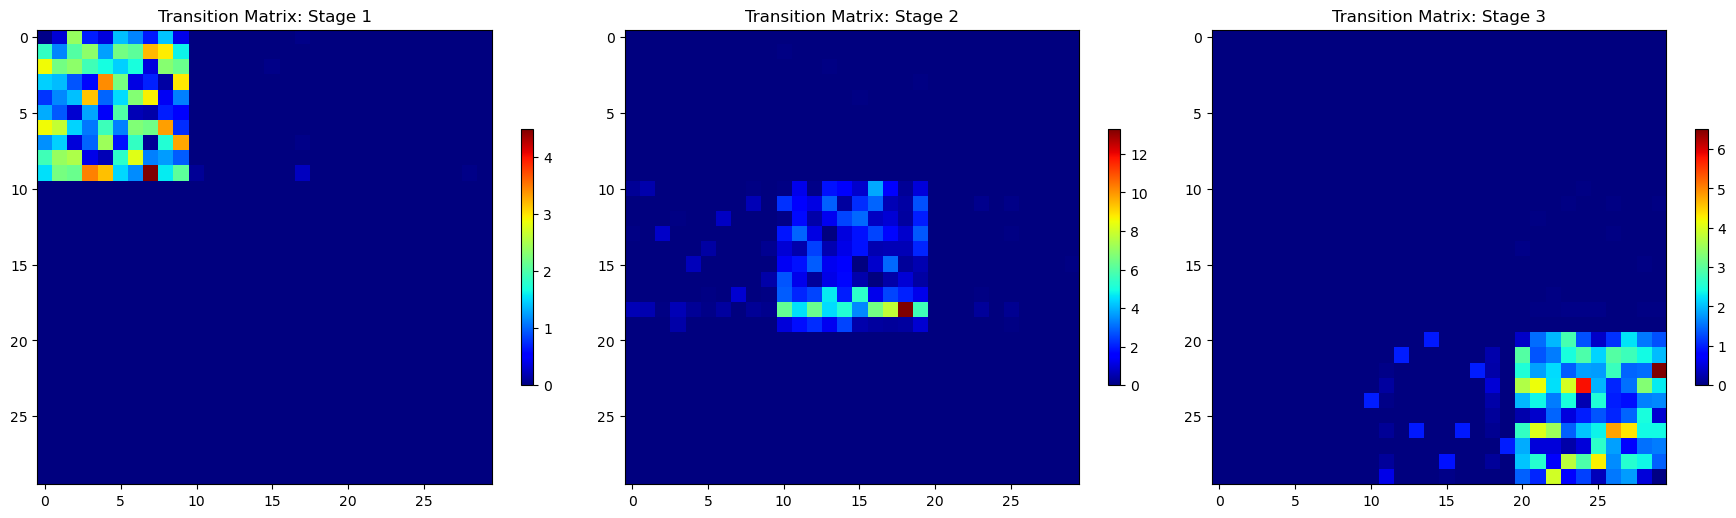

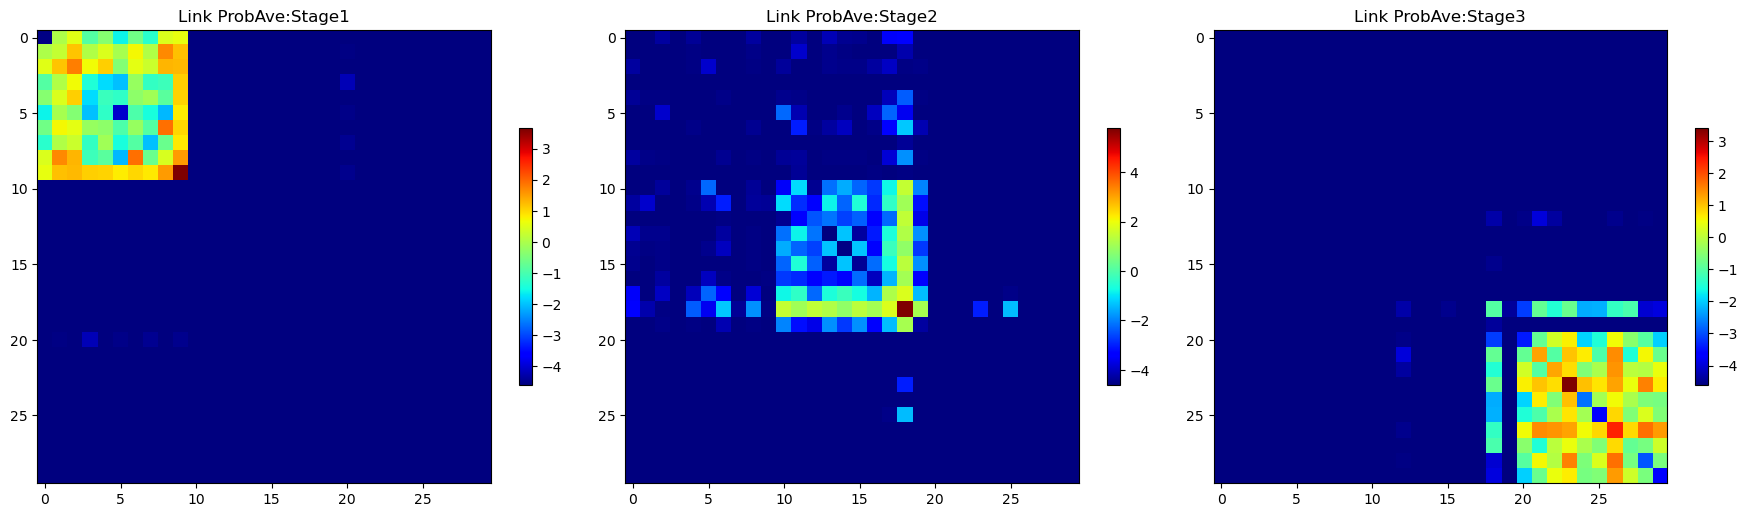

In [10]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(18,6))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[4:20], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,3, figsize = (18,6))
for i in range(3):
    if i == 0:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[4:20], axis = 0)
    else:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(torch.log(ProbAve + ProbAve.T + 0.01), cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

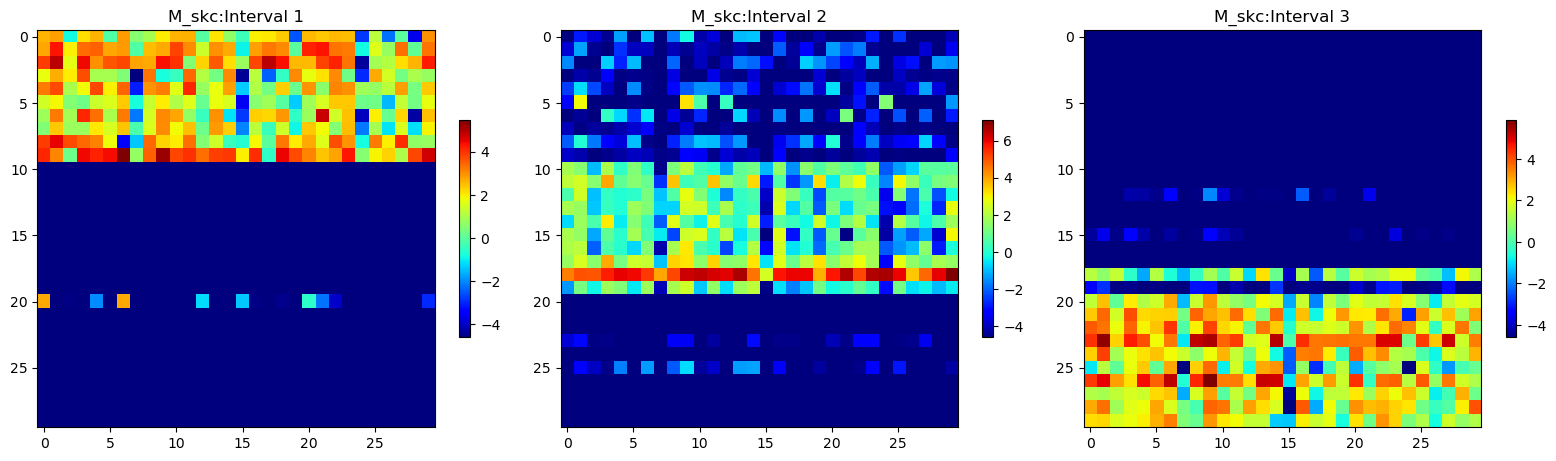

In [11]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (16,9))
for i in range(3):
    if i == 0:
        dpgm_phi = torch.sum(fs_nbrgds.fs_dpgm_model.phi[4:20], axis = 0)
    else:
        dpgm_phi = torch.sum(fs_nbrgds.fs_dpgm_model.phi[i*20:i*20+20], axis = 0) 
    latent_feature = torch.log(dpgm_phi @ fs_nbrgds.fs_dpgm_model.lam_kk + 0.01)
    im = axs[i].imshow(latent_feature, cmap='jet')
    axs[i].set_title(f'M_skc:Interval {i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.25)
plt.tight_layout()
plt.show()

# Complex case

In [12]:
# complex case
# generate sysnthetic data
T = 1000
S = 5
high_value = 10
sys = torch.zeros(T,100,100)
# interval 1
sys[0:50, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[50:100, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[100:150, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[150:200, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 2 
sys[200:250, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[250:300, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[300:350, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[350:400, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 3
sys[400:450, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[400:450, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 4
sys[600:800, 20:40,20:40] = torch.poisson(high_value * torch.ones(200, 20, 20))
sys[600:800, 60:80,60:80] = torch.poisson(high_value * torch.ones(200, 20, 20))
# interval 5
sys[800:1000, 40:60, 40:60] = torch.poisson(high_value * torch.ones(200, 20, 20))

In [13]:
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1.,
'psi':2.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 50, # latent components
'S' : 200 # sub-intervals
}

fs_nbrgds = FS_NBRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
fs_nbrgds.phi[0][:,:] = 0.
fs_nbrgds.phi[0][0:20,0:10] = 1/20
fs_nbrgds.phi[0][20:40,10:20] = 1/20
fs_nbrgds.phi[0][40:60,20:30] = 1/20
fs_nbrgds.phi[0][60:80,30:40] = 1/20
fs_nbrgds.phi[0][80:100,40:50] = 1/20
fs_nbrgds.phi[1][:,:] = 0.
fs_nbrgds.phi[1][0:20,0:10] = 1/20
fs_nbrgds.phi[1][20:40,10:20] = 1/20
fs_nbrgds.phi[1][40:60,20:30] = 1/20
fs_nbrgds.phi[1][60:80,30:40] = 1/20
fs_nbrgds.phi[1][80:100,40:50] = 1/20

initial_pi = torch.zeros(50,50)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
initial_pi[30:40, 30:40] = 1/10
initial_pi[40:50, 40:50] = 1/10
fs_nbrgds.pi  = torch.tile(initial_pi, (params['S'],1,1))
fs_nbrgds.pit = torch.tile(initial_pi, (T,1,1))
fs_nbrgds.D   = torch.ones(fs_nbrgds.K, fs_nbrgds.K)*10
# to induce m_skc to be sampled toward specfied pattern
selected_communities = torch.randint(low=0, high=50, size=(5,))
fs_nbrgds.fs_dpgm_model.phi = torch.ones_like(fs_nbrgds.fs_dpgm_model.phi) * fs_nbrgds.eps
fs_nbrgds.fs_dpgm_model.phi_o = torch.ones_like(fs_nbrgds.fs_dpgm_model.phi_o) * fs_nbrgds.eps
fs_nbrgds.fs_dpgm_model.phi[:,:,selected_communities] = 1.
fs_nbrgds.fs_dpgm_model.phi_o[:,selected_communities] = 1. 

for iter in tqdm(range(burnin+maxiter)):
    fs_nbrgds.sample_n()
    fs_nbrgds.sample_h()
    fs_nbrgds.sample_aux_h()
    fs_nbrgds.sample_the()
    fs_nbrgds.sample_lam()
    fs_nbrgds.sample_delt()
    fs_nbrgds.sample_g()
    fs_nbrgds.sample_gam()
    fs_nbrgds.sample_beta()
    fs_nbrgds.sample_phi()
    fs_nbrgds.sample_pi()
    fs_nbrgds.sample_eta()
    fs_nbrgds.sample_A()
    fs_nbrgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(fs_nbrgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 267.5276 seconds
sample_h took 2.4021 seconds
sample_aux_h took 18.7418 seconds
sample_the took 0.0094 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0171 seconds
sample_g took 0.0030 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0001 seconds
sample_phi took 1.1735 seconds
sample_pi took 1.2146 seconds
sample_eta took 0.0044 seconds
Sum over self.A:  tensor(38640)
sample_A took 84.5696 seconds
sample_dpgm took 3.1987 seconds
sample_n took 277.5214 seconds
sample_h took 2.1695 seconds
sample_aux_h took 17.3563 seconds
sample_the took 0.0101 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0174 seconds
sample_g took 0.0036 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.2111 seconds
sample_pi took 1.1421 seconds
sample_eta took 0.0045 seconds
Sum over self.A:  tensor(43140)
sample_A took 90.4912 seconds
sample_dpgm took 4.0865 seconds
sample_n took 282.1823 seconds
sample_h took 2.3041 seconds
sample_a

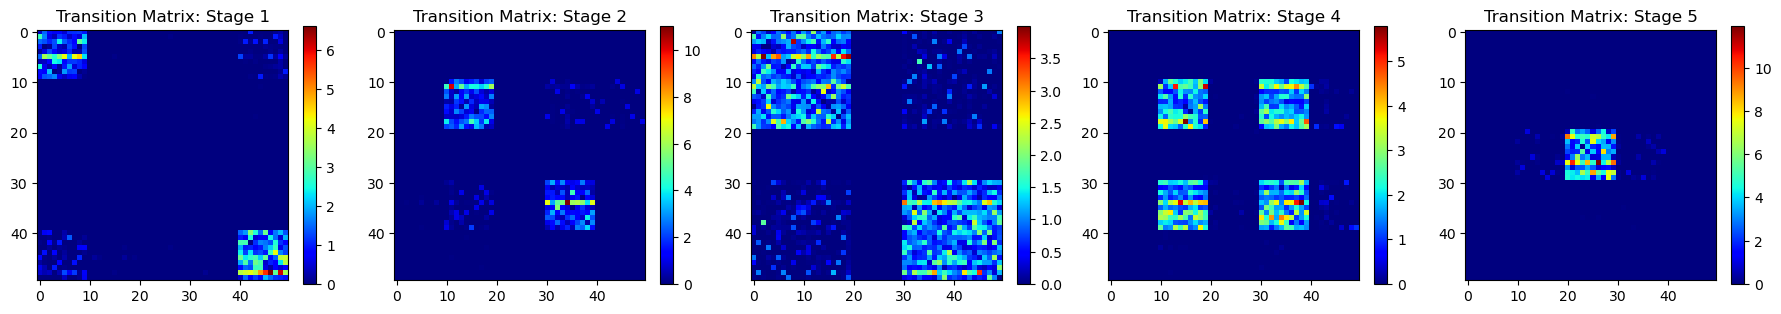

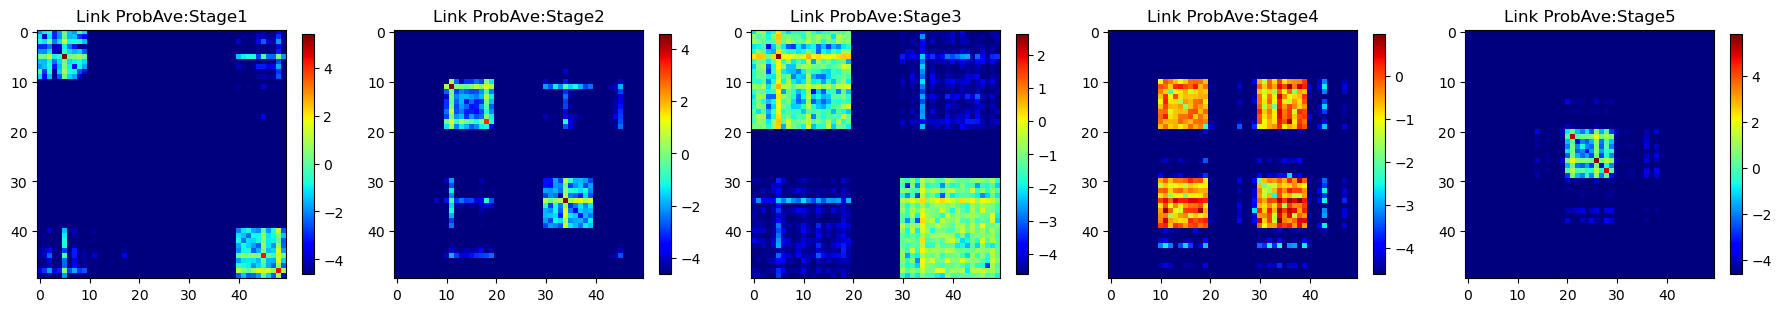

In [16]:
%matplotlib inline
#transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 5, figsize=(18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[8:40], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*40: i*40+40], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.22)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,5, figsize = (18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[8:40], axis = 0)
    else:
        ProbAve = torch.mean(fs_nbrgds.ProbAve[i*40:i*40+40], axis = 0) 
    im = ax.imshow(torch.log(ProbAve + ProbAve.T + 0.01), cmap='jet')
    ax.set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = ax, shrink=0.205)
plt.tight_layout()
plt.show()

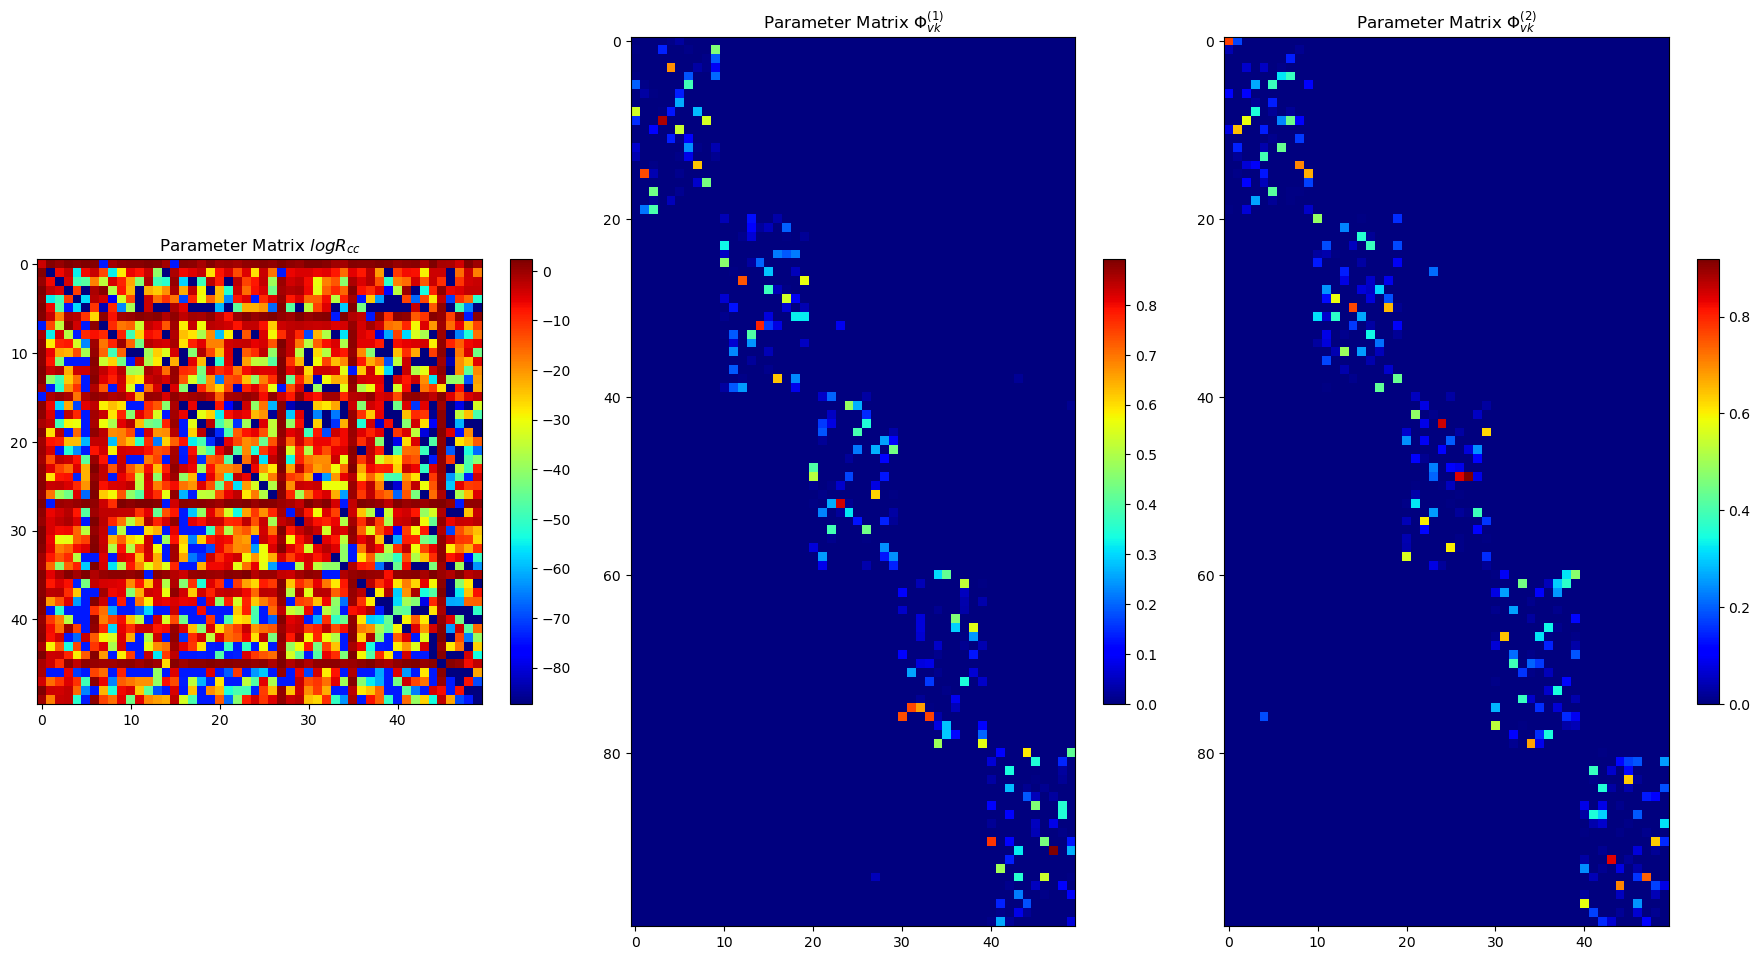

In [21]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(torch.log(fs_nbrgds.fs_dpgm_model.lam_kk), cmap = 'jet') # 用torch.log加强图像
        ax.set_title(r'Parameter Matrix $log R_{cc}$')
        cbar = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(fs_nbrgds.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(fs_nbrgds.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

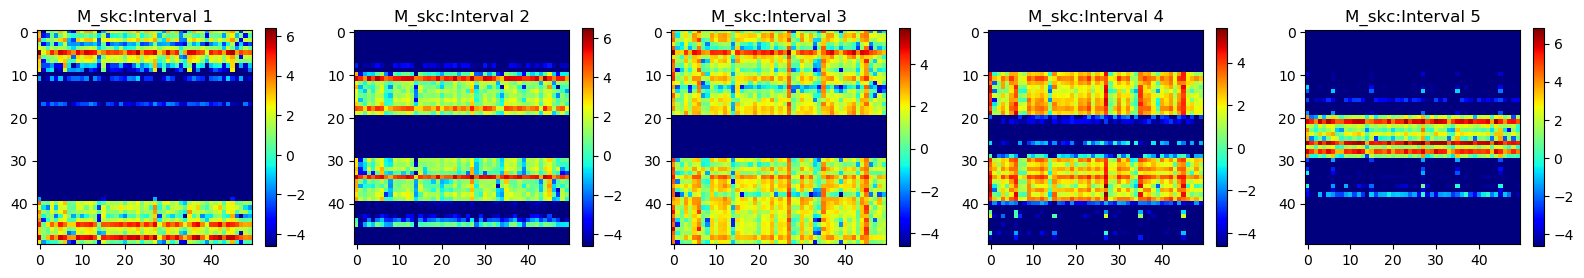

In [19]:
%matplotlib inline
fig, axs = plt.subplots(1,5, figsize = (16,9))
for i in range(5):
    if i == 0:
        dpgm_phi = torch.sum(fs_nbrgds.fs_dpgm_model.phi[8:40], axis = 0)
    else:
        dpgm_phi = torch.sum(fs_nbrgds.fs_dpgm_model.phi[i*40:i*40+40], axis = 0) 
    latent_feature = torch.log(dpgm_phi @ fs_nbrgds.fs_dpgm_model.lam_kk + 0.01)
    im = axs[i].imshow(latent_feature, cmap='jet')
    axs[i].set_title(f'M_skc:Interval {i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.25)
plt.tight_layout()
plt.show()